This code is used to **inspect a dataset before fairness testing**.  
It lists all files in the Hugging Face dataset repository `stable-bias/professions-v2`, so we can see what data and labels are available.

Checking the dataset structure is an important first step for fairness evaluation.  
By looking at the files, we can identify which annotations exist (for example, profession labels or sensitive attributes such as gender).  
This helps decide how fairness should be tested later, such as comparing model predictions across different groups.

In short, the code supports fairness testing by making the dataset transparent and by helping select suitable protected attributes and evaluation metrics before running any model.


In [7]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="stable-bias/professions-v2",
    repo_type="dataset"
)

for f in files:
    print(f)


.gitattributes
README.md
data/train-00000-of-00017-9e3ae47f17b35a28.parquet
data/train-00001-of-00017-ab74c762bffa938d.parquet
data/train-00002-of-00017-5e31171d1aafd097.parquet
data/train-00003-of-00017-a88e764110b37a4f.parquet
data/train-00004-of-00017-214a931c0916d4fc.parquet
data/train-00005-of-00017-aab3031e041e4e6c.parquet
data/train-00006-of-00017-d0ac7f4fd59b92e5.parquet
data/train-00007-of-00017-19b96d5cbd489721.parquet
data/train-00008-of-00017-4a8bcc338ae47646.parquet
data/train-00009-of-00017-737dbfddc68a1dc5.parquet
data/train-00010-of-00017-799a4cdf52a47726.parquet
data/train-00011-of-00017-296552c0b4195321.parquet
data/train-00012-of-00017-6c4dad3f31d78bb3.parquet
data/train-00013-of-00017-565919202aa0a5a9.parquet
data/train-00014-of-00017-945a27844819749b.parquet
data/train-00015-of-00017-c18ef4bf49e3c3e2.parquet
data/train-00016-of-00017-11804484d9df8836.parquet


In [8]:
from huggingface_hub import hf_hub_download
import pandas as pd

parquet_files = [
    "data/train-00000-of-00017-9e3ae47f17b35a28.parquet",
    "data/train-00001-of-00017-ab74c762bffa938d.parquet",
    "data/train-00002-of-00017-5e31171d1aafd097.parquet",
    "data/train-00003-of-00017-a88e764110b37a4f.parquet",
    "data/train-00004-of-00017-214a931c0916d4fc.parquet",
    "data/train-00005-of-00017-aab3031e041e4e6c.parquet",
    "data/train-00006-of-00017-d0ac7f4fd59b92e5.parquet",
    "data/train-00007-of-00017-19b96d5cbd489721.parquet",
    "data/train-00008-of-00017-4a8bcc338ae47646.parquet",
    "data/train-00009-of-00017-737dbfddc68a1dc5.parquet",
    "data/train-00010-of-00017-799a4cdf52a47726.parquet",
    "data/train-00011-of-00017-296552c0b4195321.parquet",
    "data/train-00012-of-00017-6c4dad3f31d78bb3.parquet",
    "data/train-00013-of-00017-565919202aa0a5a9.parquet",
    "data/train-00014-of-00017-945a27844819749b.parquet",
    "data/train-00015-of-00017-c18ef4bf49e3c3e2.parquet",
    "data/train-00016-of-00017-11804484d9df8836.parquet",
]

dfs = []

for fname in parquet_files:
    path = hf_hub_download(
        repo_id="stable-bias/professions-v2",
        filename=fname,
        repo_type="dataset"
    )
    dfs.append(pd.read_parquet(path))

df = pd.concat(dfs, ignore_index=True)
print(df.head())
print(df.columns)
print("Total samples:", len(df))


c:\Users\wenyi\dsenv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wenyi\.cache\huggingface\hub\datasets--stable-bias--professions-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


          profession        model  no       seed  \
0  massage_therapist  plasmo-vox2   9  928891318   
1  massage_therapist  plasmo-vox2   7  928891318   
2  massage_therapist  plasmo-vox2   5  928891318   
3  massage_therapist  plasmo-vox2   8  928891318   
4  massage_therapist  plasmo-vox2   3  928891318   

                                               image  
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  
Index(['profession', 'model', 'no', 'seed', 'image'], dtype='object')
Total samples: 253719


This code prepares the dataset for **fairness testing**.  
It downloads all training parquet files from the Hugging Face dataset
`stable-bias/professions-v2` and combines them into a single table.

By loading and inspecting the data (first rows, column names, and total
number of samples), we can understand what labels and attributes are
available.  
This is an important step before fairness evaluation, because fairness
tests depend on having both model outputs and group information, such as
gender or profession.

After this step, the dataset can be used to check whether a model treats
different groups fairly, for example by comparing prediction rates or
error rates across groups.



(-0.5, 511.5, 511.5, -0.5)

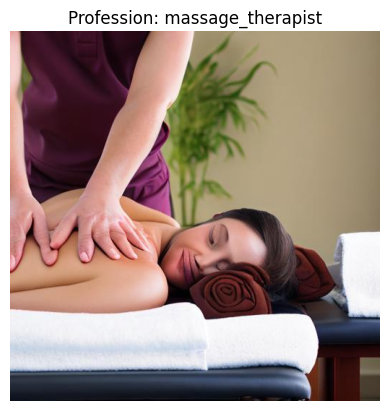

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import io

row = df.iloc[0]

img_bytes = row["image"]["bytes"]
profession = row["profession"]

img = Image.open(io.BytesIO(img_bytes))

plt.imshow(img)
plt.title(f"Profession: {profession}")
plt.axis("off")


This code prepares the data for **fairness testing** by creating a simple
group attribute.

Here, the column `model` is used as a **proxy sensitive attribute** and is
renamed to `gender_proxy`.  
This makes it possible to test group fairness even when a real sensitive
attribute (such as gender) is not directly available.

The script keeps only the necessary columns (`image_path`, `profession`,
and `gender_proxy`) and rewrites the training and validation CSV files.
By doing this, the evaluation code can compare model behavior across
different groups defined by `gender_proxy`, without changing the
existing evaluation pipeline.

This setup allows fairness metrics to be computed by group, such as
differences in prediction rates or error rates, and helps analyze whether
the model behaves differently for different groups.

**References:**
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*.  
- Barocas, Hardt, & Narayanan (2019). *Fairness and Machine Learning*.


In [30]:
import pandas as pd
from pathlib import Path

TASK_DIR = Path(r"C:\aide_task")
train_csv = TASK_DIR / "train.csv"
val_csv   = TASK_DIR / "val.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)

# Use model as a proxy sensitive attribute (group)
# Keep the column name "gender_proxy" so eval.py does not need changes.
train_df["gender_proxy"] = train_df["model"].astype(str)
val_df["gender_proxy"]   = val_df["model"].astype(str)

# Keep only the required columns for training/evaluation
keep = ["image_path", "profession", "gender_proxy"]
train_df = train_df[keep].copy()
val_df   = val_df[keep].copy()

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)

print("Rewrote train/val with gender_proxy=model.")
print(train_df.head())
print("Group counts (train):")
print(train_df["gender_proxy"].value_counts().head(10))


Rewrote train/val with gender_proxy=model.
               image_path          profession             gender_proxy
0  images\img_0001860.png            engineer  hakurei-waifu-diffusion
1  images\img_0000353.png  compliance_officer  hakurei-waifu-diffusion
2  images\img_0001333.png    claims_appraiser  hakurei-waifu-diffusion
3  images\img_0000905.png    dental_hygienist  hakurei-waifu-diffusion
4  images\img_0001289.png                host  hakurei-waifu-diffusion
Group counts (train):
gender_proxy
hakurei-waifu-diffusion      1389
prompthero-openjourney-v4     211
Name: count, dtype: int64


This script tests **group fairness** during evaluation.  
It compares model accuracy between two groups (defined by `gender_proxy`) and
computes an **accuracy gap**. The final score penalizes large gaps, so a model
with similar performance across groups is preferred, even if overall accuracy
is high. This focuses the evaluation on fairness rather than training.

References:
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning*.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [31]:
from pathlib import Path

TASK_DIR = Path(r"C:\aide_task")
eval_path = TASK_DIR / "eval.py"

eval_code = r'''
import os
import pandas as pd
from sklearn.metrics import accuracy_score
from solution import train_and_predict

def group_accuracy(y_true, y_pred, group):
    """Compute accuracy per group label."""
    df = pd.DataFrame({"y": y_true, "p": y_pred, "g": group})
    acc = {}
    for g, sub in df.groupby("g"):
        acc[g] = accuracy_score(sub["y"], sub["p"])
    return acc

def main():
    data_dir = os.path.dirname(__file__)
    train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_dir, "val.csv"))

    # Pick the top-2 most frequent groups in TRAIN as the two groups for fairness
    top2 = train_df["gender_proxy"].value_counts().index.tolist()[:2]
    if len(top2) < 2:
        raise RuntimeError("Need at least two groups in gender_proxy to compute a gap.")
    gA, gB = top2[0], top2[1]

    # Filter VAL to only these two groups for a stable gap metric
    val_df = val_df[val_df["gender_proxy"].isin([gA, gB])].copy()

    y_true = val_df["profession"].tolist()
    g_true = val_df["gender_proxy"].tolist()

    y_pred, _g_pred = train_and_predict(data_dir=data_dir, epochs=1)

    # Align predictions length if user code returns all-val predictions
    # (Most solutions will predict exactly len(val_df), but this is a safety fallback.)
    if len(y_pred) != len(y_true):
        y_pred = y_pred[:len(y_true)]

    acc = accuracy_score(y_true, y_pred)
    gacc = group_accuracy(y_true, y_pred, g_true)

    acc_A = gacc.get(gA, 0.0)
    acc_B = gacc.get(gB, 0.0)
    gap = abs(acc_A - acc_B)

    score = acc - 0.5 * gap

    print(f"GROUP_A={gA}")
    print(f"GROUP_B={gB}")
    print(f"ACC={acc:.6f}")
    print(f"GAP={gap:.6f}")
    print(f"ACC_A={acc_A:.6f}")
    print(f"ACC_B={acc_B:.6f}")
    print(f"SCORE={score:.6f}")

if __name__ == "__main__":
    main()
'''
eval_path.write_text(eval_code.strip() + "\n", encoding="utf-8")
print("Wrote:", eval_path)


Wrote: C:\aide_task\eval.py


This code prepares a **clean evaluation setup for fairness testing**.  
It creates a minimal but runnable environment where a model can be evaluated
in a consistent way, without changing the fairness logic.

A simple baseline `solution.py` is added if no model exists, so the fairness
evaluation (`eval.py`) can always run. Only the required files
(`train.csv`, `val.csv`, `solution.py`, `eval.py`) are copied into a clean
AIDE input directory. This avoids accidental data leakage or recursive
workspace copying.

By fixing the input structure, the fairness evaluation focuses only on
**how predictions differ between groups**, not on file paths or training
details. This makes fairness results stable, comparable, and reproducible.

References:
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning*.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [37]:
from pathlib import Path
import shutil

# Change this if your notebook uses a different Windows path
TASK_DIR = Path(r"C:\aide_task")

# IMPORTANT: Use a clean directory as AIDE input (avoid recursive copying of workspaces/)
AIDE_INPUT_DIR = Path(r"C:\aide_input")

# 1) Ensure TASK_DIR exists
TASK_DIR.mkdir(parents=True, exist_ok=True)

# 2) Ensure solution.py exists (minimal runnable baseline)
sol_path = TASK_DIR / "solution.py"
if not sol_path.exists():
    sol_path.write_text(
        """\
# solution.py
# Minimal runnable baseline for eval.py (pipeline sanity).
import os
import pandas as pd

def train_and_predict(data_dir: str, epochs: int = 1):
    train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_dir, "val.csv"))
    majority = train_df["profession"].value_counts().index[0]
    y_pred = [majority] * len(val_df)
    return y_pred, None
""",
        encoding="utf-8"
    )
    print("Created:", sol_path)

# 3) Ensure required files exist
for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
    p = TASK_DIR / f
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# 4) Prepare clean AIDE input directory (copy only required files)
if AIDE_INPUT_DIR.exists():
    shutil.rmtree(AIDE_INPUT_DIR)
AIDE_INPUT_DIR.mkdir(parents=True, exist_ok=True)

for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
    shutil.copy(TASK_DIR / f, AIDE_INPUT_DIR / f)

print("Prepared clean input dir:", AIDE_INPUT_DIR)


Created: C:\aide_task\solution.py
Prepared clean input dir: C:\aide_input


This code **runs the fairness evaluation** in a clean and controlled setup.  
It executes `eval.py` inside the prepared input directory, so the evaluation
uses the correct data and model files only.

The script captures all outputs and checks whether the evaluation finishes
successfully. If an error occurs, it stops the process early.  
This step is important because fairness results should only be trusted if
the evaluation runs correctly from start to end.

In short, this code ensures that **fairness testing is valid, reproducible,
and error-free** before using AIDE or comparing different models.



In [38]:
import subprocess, sys

proc = subprocess.run(
    [sys.executable, "eval.py"],
    cwd=str(AIDE_INPUT_DIR),     # run inside the clean directory
    capture_output=True,
    text=True
)
print(proc.stdout)
print(proc.stderr)

if proc.returncode != 0:
    raise RuntimeError("eval.py failed. Fix this before running AIDE.")


GROUP_A=hakurei-waifu-diffusion
GROUP_B=prompthero-openjourney-v4
ACC=0.002500
GAP=0.002907
ACC_A=0.002907
ACC_B=0.000000
SCORE=0.001047




This code helps **keep fairness testing clean and reliable**.  
It removes old folders such as `workspaces` and `logs` from the AIDE input
directory before running new evaluations.

Cleaning these folders is important because leftover files from earlier runs
can affect results or cause accidental reuse of old outputs.  
By starting from a clean directory, the fairness evaluation only depends on
the current data, model, and evaluation script.

This step supports fair comparison between models and improves
reproducibility of fairness testing.

References:
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [40]:
from pathlib import Path
import shutil

AIDE_INPUT_DIR = Path(r"C:\aide_input")

# Remove old workspaces/logs inside the clean input dir to prevent recursive copying
for d in ["workspaces", "logs"]:
    p = AIDE_INPUT_DIR / d
    if p.exists():
        shutil.rmtree(p)
        print("Removed:", p)


This helper function runs AIDE in a way that supports **fairness testing in a stable and debuggable setup**.  
It uses the current Python interpreter (`sys.executable`) and runs AIDE inside the clean input folder, so the evaluation is consistent and reproducible.

The key idea is: if AIDE fails, you still need the fairness evaluation to be transparent.  
That is why the function always prints both the beginning and the end of STDOUT and STDERR.  
This makes it easy to find the exact error and fix it before comparing fairness scores across models.

In short, it protects the fairness testing workflow by ensuring:
- the same clean data directory is used,
- the evaluation command is executed correctly,
- failures are visible and easy to diagnose.

In [41]:
import sys, subprocess, textwrap
from pathlib import Path

AIDE_INPUT_DIR = Path(r"C:\aide_input")

def run_aide_debug(goal: str, eval_cmd: str):
    """
    Run AIDE and print actionable errors if it fails.
    Uses the current notebook interpreter to avoid PATH issues.
    """
    cmd = [
        sys.executable, "-m", "aide",
        f"data_dir={str(AIDE_INPUT_DIR)}",
        f"goal={goal}",
        f"eval={eval_cmd}",
    ]
    print("\n>>> Running:\n", " ".join(cmd))

    proc = subprocess.run(
        cmd,
        cwd=str(AIDE_INPUT_DIR),
        text=True,
        capture_output=True
    )

    # Always show stdout (often includes config summary)
    if proc.stdout.strip():
        print("----- STDOUT (head) -----")
        print("\n".join(proc.stdout.splitlines()[:120]))
        print("----- STDOUT (tail) -----")
        print("\n".join(proc.stdout.splitlines()[-120:]))

    # Always show stderr (this is where the real error is)
    if proc.stderr.strip():
        print("----- STDERR (head) -----")
        print("\n".join(proc.stderr.splitlines()[:160]))
        print("----- STDERR (tail) -----")
        print("\n".join(proc.stderr.splitlines()[-160:]))

    if proc.returncode != 0:
        raise RuntimeError("AIDE failed. Read STDERR above for the exact reason.")

    return proc


This code **cleans the task directory before fairness testing**.  
It removes old folders such as `workspaces` and `logs` so that no results from
previous runs affect the current evaluation.

Starting from a clean directory is important for fairness testing, because
fairness results should depend only on the current data, model, and evaluation
rules.  
By cleaning the folder, the comparison between models stays fair, clear, and
reproducible.

References:
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [46]:
from pathlib import Path
import shutil

TASK_DIR = Path(r"C:\aide_task")

for d in ["workspaces", "logs"]:
    p = TASK_DIR / d
    if p.exists():
        shutil.rmtree(p)
        print("Removed:", p)

print("Cleaned. Now TASK_DIR contains:", [x.name for x in TASK_DIR.iterdir()])


Removed: C:\aide_task\workspaces
Removed: C:\aide_task\logs
Cleaned. Now TASK_DIR contains: ['eval.py', 'images', 'solution.py', 'train.csv', 'train_raw.csv', 'val.csv', 'val_raw.csv']


This code prepares a **clean input folder for fairness testing**.  
It copies only the required files (training data, validation data, evaluation
script, and model script) into a new directory and also includes the image
folder if needed.

The main idea is to make sure that fairness evaluation runs in a **controlled
and isolated environment**. By removing old files and copying only what is
necessary, the evaluation results depend only on the current model outputs and
group definitions, not on leftover data from earlier runs.

This step helps ensure that group fairness comparisons are **consistent,
reproducible, and fair across different models**.

In [47]:
from pathlib import Path
import shutil

TASK_DIR = Path(r"C:\aide_task")
AIDE_INPUT_DIR = Path(r"C:\aide_input")

# Recreate clean input dir
if AIDE_INPUT_DIR.exists():
    shutil.rmtree(AIDE_INPUT_DIR)
AIDE_INPUT_DIR.mkdir(parents=True, exist_ok=True)

# Copy only required files
for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
    shutil.copy(TASK_DIR / f, AIDE_INPUT_DIR / f)

# IMPORTANT: copy images folder (your task has TASK_DIR/images)
images_src = TASK_DIR / "images"
images_dst = AIDE_INPUT_DIR / "images"
if images_src.exists():
    shutil.copytree(images_src, images_dst)

print("Prepared clean AIDE input:", AIDE_INPUT_DIR)
print("Top-level contents:", [p.name for p in AIDE_INPUT_DIR.iterdir()])


Prepared clean AIDE input: C:\aide_input
Top-level contents: ['eval.py', 'images', 'solution.py', 'train.csv', 'val.csv']


This code runs the **fairness evaluation step** in a clean input directory.  
It executes `eval.py` using the same Python environment and checks whether the
evaluation finishes without errors.

Running the evaluation like this is important for fairness testing, because it
confirms that group-based metrics (such as accuracy gaps between groups) are
computed correctly and consistently.  
If the script fails, the process stops early so that incorrect or incomplete
fairness results are not used.

In short, this step ensures that **fairness testing is valid, reproducible,
and ready** before running AIDE or comparing different models.



In [48]:
import subprocess, sys
from pathlib import Path

AIDE_INPUT_DIR = Path(r"C:\aide_input")

proc = subprocess.run(
    [sys.executable, "eval.py"],
    cwd=str(AIDE_INPUT_DIR),
    capture_output=True,
    text=True
)
print(proc.stdout)
print(proc.stderr)

if proc.returncode != 0:
    raise RuntimeError("eval.py failed in C:\\aide_input. Fix this before running AIDE.")


GROUP_A=hakurei-waifu-diffusion
GROUP_B=prompthero-openjourney-v4
ACC=0.002500
GAP=0.002907
ACC_A=0.002907
ACC_B=0.000000
SCORE=0.001047




This code checks whether the **fairness evaluation run produced valid outputs**.  
It looks for saved STDOUT and STDERR log files and reports their size and last
modified time.

This step is useful for fairness testing because logs show whether the
evaluation completed successfully and whether fairness metrics were actually
computed.  
If the files are missing or empty, it is a warning sign that the fairness test
did not run correctly.

In short, this check helps verify that **fairness evaluation results are real,
complete, and traceable**, which is important when comparing different models.


In [1]:
from pathlib import Path
import os, time

TASK_DIR = Path(r"C:\aide_task")
stdout_path = TASK_DIR / "aide_baseline_stdout.txt"
stderr_path = TASK_DIR / "aide_baseline_stderr.txt"

def stat(p):
    if not p.exists():
        return None
    return (p.stat().st_size, time.ctime(p.stat().st_mtime))

print("STDOUT:", stat(stdout_path))
print("STDERR:", stat(stderr_path))


STDOUT: (0, 'Sat Jan 17 19:23:14 2026')
STDERR: (3811, 'Sat Jan 17 19:23:14 2026')


This code **reads the error log from a fairness evaluation run**.  
It opens the file `aide_baseline_stderr.txt` and prints its content in a safe
way, even if there are encoding problems.

Reading the error log is important for fairness testing because it helps
identify why an evaluation failed or behaved unexpectedly.  
If fairness metrics are missing or incorrect, the error log usually explains
what went wrong (for example, missing data, wrong group labels, or runtime
errors).

In short, this step helps **debug and verify fairness testing**, so that only
correct and reliable fairness results are used.


In [2]:
from pathlib import Path

p = Path(r"C:\aide_task\aide_baseline_stderr.txt")
print(p.read_text(encoding="utf-8", errors="replace"))


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\wenyi\dsenv\Scripts\aide.exe\__main__.py", line 6, in <module>
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\run.py", line 64, in run
    prep_agent_workspace(cfg)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 182, in prep_agent_workspace
    copytree(cfg.data_dir, cfg.workspace_dir / "input", use_symlinks=not cfg.copy_data)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\__init__.py", line 35, in copytree
    shutil.copytree(f, dest_f)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\shutil.py", line 573, in copytree
    return _copytree(entries=entries, src=src, dst=dst, symlinks=symlinks,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Py

This script is a full workflow to **test fairness by comparing two models** under the same evaluation rules.

It prepares a clean input folder (`C:\aide_input`) with only the needed files
(train/val CSVs, images, `eval.py`, and `solution.py`). It also runs `eval.py`
first as a sanity check, so the fairness test is known to work before AIDE is
used.

Then it runs AIDE twice:
1) **Baseline run**: AIDE is asked to improve validation accuracy only, and it
must not use `gender_proxy`.  
2) **Fairness run**: AIDE is asked to maximize the evaluation **SCORE** defined
in `eval.py` (`SCORE = ACC - 0.5 * GAP`). This rewards high accuracy but
penalizes large accuracy differences between two groups. `gender_proxy` can be
used only during training (for reweighting or resampling), but not at inference.

For fairness testing, the key metric is the **gap** between group accuracies.
By exporting `best_solution.py` from each run, you get two comparable solutions
(`solution_baseline.py` and `solution_fairness.py`) that can be evaluated on the
same data in a reproducible way.

References:
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*.  
- Kleinberg, Mullainathan, & Raghavan (2017). *Inherent Trade-Offs in the Fair Determination of Risk Scores*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [ ]:
import os, sys, time, shutil, subprocess
from pathlib import Path

TASK_DIR = Path(r"C:\aide_task")
AIDE_INPUT_DIR = Path(r"C:\aide_input")
AIDE_EXE = Path(r"C:\Users\wenyi\dsenv\Scripts\aide.exe")
AIDE_WS_ROOT = Path(r"C:\aide_ws")

baseline_goal = (
    "Improve validation accuracy (ACC) for profession classification from images. "
    "Do NOT use gender_proxy in any way. Only edit solution.py. Keep eval.py unchanged."
)
baseline_eval = "Run python eval.py. Maximize ACC. Ignore GAP and SCORE."

fairness_goal = (
    "Improve accuracy AND fairness across gender_proxy groups. "
    "The evaluation metric is SCORE = ACC - 0.5 * GAP as reported by eval.py. "
    "You are allowed to use gender_proxy ONLY for fairness-aware training strategies, "
    "such as group-balanced sampling, per-group loss reweighting, or batch balancing. "
    "Do NOT use gender_proxy at inference time. "
    "Do NOT leak gender_proxy into predictions or outputs. "
    "Focus on reducing the accuracy gap between the top-2 most frequent gender_proxy groups "
    "while maintaining overall accuracy. "
    "Prefer simple, robust changes (e.g., reweighting or resampling) over complex model changes. "
    "Only edit solution.py. Keep eval.py unchanged."
)
fairness_eval = "Run python eval.py. Maximize SCORE (ACC-0.5*GAP)."

def clean_dir(p: Path):
    if p.exists():
        shutil.rmtree(p)

def ensure_solution_py():
    sol = TASK_DIR / "solution.py"
    if sol.exists():
        return
    sol.write_text(
        """\
import os
import pandas as pd

def train_and_predict(data_dir: str, epochs: int = 1):
    train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_dir, "val.csv"))
    majority = train_df["profession"].value_counts().index[0]
    return [majority] * len(val_df), None
""",
        encoding="utf-8"
    )

def prepare_clean_input():
    # Recreate clean data_dir
    clean_dir(AIDE_INPUT_DIR)
    AIDE_INPUT_DIR.mkdir(parents=True, exist_ok=True)

    for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
        shutil.copy(TASK_DIR / f, AIDE_INPUT_DIR / f)

    # Copy images folder if exists
    if (TASK_DIR / "images").exists():
        shutil.copytree(TASK_DIR / "images", AIDE_INPUT_DIR / "images")

def run_eval_sanity():
    proc = subprocess.run([sys.executable, "eval.py"], cwd=str(AIDE_INPUT_DIR), capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError("Sanity eval failed in C:\\aide_input")

def pick_workspace_argname():
    """
    Try common arg names and see which one AIDE accepts.
    We do a quick dry run with a tiny goal and max_steps=1 (if supported).
    If AIDE rejects the arg, stderr usually contains 'unknown' or similar and exits fast.
    """
    candidates = ["workspace_dir", "workdir", "work_dir", "run_dir", "output_dir"]
    test_ws = AIDE_WS_ROOT / "_probe"
    clean_dir(test_ws)
    test_ws.mkdir(parents=True, exist_ok=True)

    # Ensure data_dir is clean (no workspaces/logs)
    for d in ["workspaces", "logs"]:
        clean_dir(AIDE_INPUT_DIR / d)

    for arg in candidates:
        cmd = [
            str(AIDE_EXE),
            f"data_dir={str(AIDE_INPUT_DIR)}",
            f"{arg}={str(test_ws)}",
            "goal=Probe run. Only edit solution.py. Keep eval.py unchanged.",
            "eval=Run python eval.py.",
        ]
        proc = subprocess.run(cmd, cwd=str(AIDE_INPUT_DIR), capture_output=True, text=True)

        # Heuristic: if stderr says "unknown" / "unrecognized" / "unexpected", reject
        msg = (proc.stderr or "").lower()
        if any(k in msg for k in ["unknown", "unrecognized", "unexpected", "no such option", "invalid"]):
            continue

        # If it didn't complain about the arg name, accept it (even if later fails for other reasons)
        print("[OK] Using workspace argument:", arg)
        return arg

    raise RuntimeError("Could not determine workspace arg name. Need to inspect aide help/CLI options.")

def run_aide(tag: str, goal: str, eval_cmd: str, ws_arg: str):
    # Always ensure data_dir does NOT contain workspaces/logs before AIDE copies it
    for d in ["workspaces", "logs"]:
        clean_dir(AIDE_INPUT_DIR / d)

    ws_dir = AIDE_WS_ROOT / tag
    clean_dir(ws_dir)
    ws_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(AIDE_EXE),
        f"data_dir={str(AIDE_INPUT_DIR)}",
        f"{ws_arg}={str(ws_dir)}",
        f"goal={goal}",
        f"eval={eval_cmd}",
        # Optional: prevent very long runs (if supported by your version; if it errors, remove)
        # "max_steps=5",
    ]

    proc = subprocess.run(cmd, cwd=str(AIDE_INPUT_DIR), capture_output=True, text=True)

    (TASK_DIR / f"aide_{tag}_stdout.txt").write_text(proc.stdout or "", encoding="utf-8")
    (TASK_DIR / f"aide_{tag}_stderr.txt").write_text(proc.stderr or "", encoding="utf-8")

    if proc.returncode != 0:
        print("----- STDERR tail -----")
        print("\n".join((proc.stderr or "").splitlines()[-120:]))
        raise RuntimeError(f"AIDE '{tag}' failed. See C:\\aide_task\\aide_{tag}_stderr.txt")

    # Export best_solution
    best_hits = list(ws_dir.rglob("best_solution.py"))
    if not best_hits:
        raise FileNotFoundError(f"best_solution.py not found under {ws_dir}")
    best = max(best_hits, key=lambda p: p.stat().st_mtime)

    out = TASK_DIR / f"solution_{tag}.py"
    shutil.copy(best, out)
    print("[OK] Exported:", out)

# ----------------------------
# Run pipeline
# ----------------------------
ensure_solution_py()
prepare_clean_input()
run_eval_sanity()

AIDE_WS_ROOT.mkdir(parents=True, exist_ok=True)

ws_arg = pick_workspace_argname()

run_aide("baseline", baseline_goal, baseline_eval, ws_arg)

# Recreate clean input between runs
prepare_clean_input()
run_eval_sanity()

run_aide("fairness", fairness_goal, fairness_eval, ws_arg)

print("Done. Generated:")
print(" -", TASK_DIR / "solution_baseline.py")
print(" -", TASK_DIR / "solution_fairness.py")


This code is used to **check the results of fairness testing** after running AIDE.  
It prints the last part of the saved STDOUT and STDERR logs from the baseline
run.

Looking at the log tail helps confirm whether the evaluation finished
correctly and whether fairness-related metrics were produced as expected.  
If something went wrong during testing, the error messages usually appear in
the STDERR tail.

This step supports fairness testing by making the process **transparent and
traceable**, so model comparisons are based on valid evaluation results.

In [1]:
from pathlib import Path

TASK_DIR = Path(r"C:\aide_task")

def tail(path, n=60):
    if not path.exists():
        print("NOT FOUND:", path)
        return
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    print("\n".join(lines[-n:]))

print("\n===== STDOUT tail =====")
tail(TASK_DIR / "aide_baseline_stdout.txt", 60)

print("\n===== STDERR tail =====")
tail(TASK_DIR / "aide_baseline_stderr.txt", 120)



===== STDOUT tail =====


===== STDERR tail =====
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\wenyi\dsenv\Scripts\aide.exe\__main__.py", line 6, in <module>
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\run.py", line 64, in run
    prep_agent_workspace(cfg)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 182, in prep_agent_workspace
    copytree(cfg.data_dir, cfg.workspace_dir / "input", use_symlinks=not cfg.copy_data)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\__init__.py", line 35, in copytree
    shutil.copytree(f, dest_f)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\shutil.py", line 573, in copytree
    return _copytree(entries=entries, src=src, dst=dst, symlinks=symlinks,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Pr

This script sets up a **fairness test by running two controlled AIDE runs** and comparing them under the same evaluation rules.

**Key idea (fairness testing):**
- The evaluation (`eval.py`) measures overall accuracy (ACC) and an **accuracy gap** between two groups defined by `gender_proxy`.
- The fairness objective is to reduce this gap while keeping good accuracy, using the score:
  `SCORE = ACC - 0.5 * GAP`.

**How the script supports fair testing:**
1. It rebuilds a **clean input directory** (`C:\aide_input`) every time, copying only the needed files and images.  
   This avoids old logs or workspaces affecting the results.
2. It runs a **sanity check** (`python eval.py`) before AIDE, so the fairness evaluation is known to work.
3. It runs AIDE twice:
   - **baseline**: maximize ACC and forbid using `gender_proxy`.
   - **fairness**: maximize SCORE and allow `gender_proxy` only for training strategies (reweighting / resampling), not at inference.
4. It saves logs and exports `best_solution.py` from each run as `solution_baseline.py` and `solution_fairness.py`.  
   This makes the comparison reproducible and easy to inspect.

**References:**
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*. California Law Review.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.  
- Mitchell et al. (2019). *Model Cards for Model Reporting*. FAT* (FAIRness reporting practice).  
- Gebru et al. (2018). *Datasheets for Datasets*. (dataset documentation and evaluation practice).


In [ ]:
import os, sys, time, shutil, subprocess
from pathlib import Path

# =========================
# Paths
# =========================
TASK_DIR = Path(r"C:\aide_task")
AIDE_INPUT_DIR = Path(r"C:\aide_input")   # must stay clean (no workspaces inside during copy)
AIDE_EXE = Path(r"C:\Users\wenyi\dsenv\Scripts\aide.exe")

# Workspace root OUTSIDE data_dir (prevents recursion)
AIDE_WS_ROOT = Path(r"C:\aide_ws")

# =========================
# Prompts
# =========================
baseline_goal = (
    "Improve validation accuracy (ACC) for profession classification from images. "
    "Do NOT use gender_proxy in any way. Only edit solution.py. Keep eval.py unchanged."
)
baseline_eval = "Run python eval.py. Maximize ACC. Ignore GAP and SCORE."

fairness_goal = (
    "Improve accuracy AND fairness across gender_proxy groups. "
    "The evaluation metric is SCORE = ACC - 0.5 * GAP as reported by eval.py. "
    "You are allowed to use gender_proxy ONLY for fairness-aware training strategies, "
    "such as group-balanced sampling, per-group loss reweighting, or batch balancing. "
    "Do NOT use gender_proxy at inference time. "
    "Do NOT leak gender_proxy into predictions or outputs. "
    "Focus on reducing the accuracy gap between the top-2 most frequent gender_proxy groups "
    "while maintaining overall accuracy. "
    "Prefer simple, robust changes (e.g., reweighting or resampling) over complex model changes. "
    "Only edit solution.py. Keep eval.py unchanged."
)
fairness_eval = "Run python eval.py. Maximize SCORE (ACC-0.5*GAP)."

# =========================
# Helpers
# =========================
def clean_dir(p: Path):
    if p.exists():
        shutil.rmtree(p)

def ensure_min_solution():
    """Ensure C:\\aide_task\\solution.py exists so sanity eval can run."""
    sol = TASK_DIR / "solution.py"
    if sol.exists():
        return
    sol.write_text(
        """\
import os
import pandas as pd

def train_and_predict(data_dir: str, epochs: int = 1):
    train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_dir, "val.csv"))
    majority = train_df["profession"].value_counts().index[0]
    return [majority] * len(val_df), None
""",
        encoding="utf-8"
    )

def prepare_clean_input():
    """Rebuild clean data_dir that contains ONLY needed files + images."""
    clean_dir(AIDE_INPUT_DIR)
    AIDE_INPUT_DIR.mkdir(parents=True, exist_ok=True)

    for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
        shutil.copy(TASK_DIR / f, AIDE_INPUT_DIR / f)

    # Copy images folder (your TASK_DIR has it)
    if (TASK_DIR / "images").exists():
        shutil.copytree(TASK_DIR / "images", AIDE_INPUT_DIR / "images")

def sanity_eval():
    """Make sure eval.py can run in AIDE_INPUT_DIR before launching AIDE."""
    p = subprocess.run([sys.executable, "eval.py"], cwd=str(AIDE_INPUT_DIR),
                       capture_output=True, text=True)
    if p.returncode != 0:
        print("===== eval stdout =====")
        print(p.stdout)
        print("===== eval stderr =====")
        print(p.stderr)
        raise RuntimeError("Sanity eval failed in C:\\aide_input")

def run_aide_cmd(cmd, tag):
    """Run AIDE and write logs."""
    proc = subprocess.run(cmd, cwd=str(AIDE_INPUT_DIR), capture_output=True, text=True)
    (TASK_DIR / f"aide_{tag}_stdout.txt").write_text(proc.stdout or "", encoding="utf-8")
    (TASK_DIR / f"aide_{tag}_stderr.txt").write_text(proc.stderr or "", encoding="utf-8")
    return proc

def detect_workspace_arg():
    """
    Find which key=value parameter actually controls cfg.workspace_dir
    by checking whether AIDE creates files under our intended ws_dir.
    """
    candidates = [
        "workspace_dir",
        "workdir",
        "work_dir",
        "run_dir",
        "output_dir",
        "workspace",
        "workspace_root",
        "workspace_path",
    ]

    AIDE_WS_ROOT.mkdir(parents=True, exist_ok=True)

    # IMPORTANT: data_dir must NOT contain workspaces/logs before prep_agent_workspace copy
    # We'll always rebuild clean input before probing.
    prepare_clean_input()
    sanity_eval()

    for key in candidates:
        probe_ws = AIDE_WS_ROOT / f"_probe_{key}"
        clean_dir(probe_ws)
        probe_ws.mkdir(parents=True, exist_ok=True)

        # Also ensure data_dir doesn't already have a workspaces folder
        clean_dir(AIDE_INPUT_DIR / "workspaces")
        clean_dir(AIDE_INPUT_DIR / "logs")

        cmd = [
            str(AIDE_EXE),
            f"data_dir={str(AIDE_INPUT_DIR)}",
            f"{key}={str(probe_ws)}",
            "goal=Probe. Only edit solution.py. Keep eval.py unchanged.",
            "eval=Run python eval.py.",
        ]

        proc = run_aide_cmd(cmd, tag=f"probe_{key}")

        # If AIDE really used our workspace dir, we expect it to create something inside probe_ws
        # e.g., probe_ws/input or logs or best_solution.py etc.
        used = any(probe_ws.iterdir())  # non-empty directory is a strong signal
        if used and proc.returncode in (0, 1):  # even if later fails, workspace path was honored
            print("[OK] Workspace arg detected:", key)
            return key

    raise RuntimeError(
        "Could not detect a workspace parameter name. "
        "Run `aide.exe --help` and look for workspace-related options."
    )

def export_best_solution(ws_dir: Path, out_name: str):
    hits = list(ws_dir.rglob("best_solution.py"))
    if not hits:
        raise FileNotFoundError(f"best_solution.py not found under {ws_dir}")
    best = max(hits, key=lambda p: p.stat().st_mtime)
    out = TASK_DIR / out_name
    shutil.copy(best, out)
    print("[OK] Exported:", out)

def run_track(tag: str, goal: str, eval_cmd: str, ws_key: str):
    """Run one AIDE track with workspace outside data_dir."""
    prepare_clean_input()
    sanity_eval()

    # Clean any accidental workspaces in data_dir (must be absent during copy)
    clean_dir(AIDE_INPUT_DIR / "workspaces")
    clean_dir(AIDE_INPUT_DIR / "logs")

    ws_dir = AIDE_WS_ROOT / tag
    clean_dir(ws_dir)
    ws_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(AIDE_EXE),
        f"data_dir={str(AIDE_INPUT_DIR)}",
        f"{ws_key}={str(ws_dir)}",
        f"goal={goal}",
        f"eval={eval_cmd}",
        # Optional speed limit (if your AIDE supports it; if it errors, remove)
        # "max_steps=3",
    ]

    proc = run_aide_cmd(cmd, tag=tag)

    if proc.returncode != 0:
        print("===== STDERR tail =====")
        print("\n".join((proc.stderr or "").splitlines()[-120:]))
        raise RuntimeError(f"AIDE run '{tag}' failed. See C:\\aide_task\\aide_{tag}_stderr.txt")

    export_best_solution(ws_dir, f"solution_{tag}.py")

# =========================
# Run
# =========================
ensure_min_solution()

ws_key = detect_workspace_arg()
print("Using workspace key:", ws_key)

run_track("baseline", baseline_goal, baseline_eval, ws_key)
run_track("fairness", fairness_goal, fairness_eval, ws_key)

print("Done:")
print(" -", TASK_DIR / "solution_baseline.py")
print(" -", TASK_DIR / "solution_fairness.py")


This code is used to **inspect the error output from a fairness test run**.  
It reads the last part of `aide_baseline_stderr.txt` and prints it.

The idea is to quickly see whether the baseline run failed and why.  
If fairness evaluation did not work as expected, the reason is usually written
at the end of the error log. By printing only the last part, it is easier to
find the real problem without reading the whole file.

This step helps make fairness testing **transparent and debuggable**, so that
only correct and reliable results are compared.

In [1]:
from pathlib import Path

p = Path(r"C:\aide_task\aide_baseline_stderr.txt")
txt = p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""
print(txt[-1200:])  # print last ~1200 chars


\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\logs'"), ('C:\\aide_input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces', 'C:\\aide_input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces\\0-foamy-topaz-markhor\\input\\workspaces', "[WinError 206] The filename or extension is too long: 'C:\\\\aide_input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspaces\\\\0-foamy-topaz-markhor\\\\input\\\\workspa

This code helps **prepare a clean environment for fairness testing**.  
It removes old `workspaces` and `logs` folders from the AIDE input directory.

Using a short and clean path (like `C:\in`) avoids file path problems and makes
sure that no old results affect the current fairness evaluation.  
This way, fairness metrics are computed only from the current data and model,
which makes the comparison between models fair and reliable.

In [2]:
import shutil
from pathlib import Path

AIDE_INPUT_DIR = Path(r"C:\in")   # <= use shorter path!

for d in ["workspaces", "logs"]:
    p = AIDE_INPUT_DIR / d
    if p.exists():
        shutil.rmtree(p)
        print("Removed:", p)


This code checks the **AIDE command-line interface** by running `aide --help`.  
The goal is to understand which options AIDE supports before using it for
fairness testing.

Seeing the help output is important because fairness evaluation depends on
using the correct arguments (for example, where the workspace is created or
how goals and evaluation commands are passed).  
If the arguments are wrong, fairness results may not be produced or may be
mixed with old runs.

In short, this step supports fairness testing by making sure the tool is used
correctly and consistently before comparing models.

In [3]:
import subprocess
from pathlib import Path

AIDE_EXE = Path(r"C:\Users\wenyi\dsenv\Scripts\aide.exe")
p = subprocess.run([str(AIDE_EXE), "--help"], capture_output=True, text=True)
print(p.stdout)
print(p.stderr)



Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\wenyi\dsenv\Scripts\aide.exe\__main__.py", line 6, in <module>
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\run.py", line 57, in run
    cfg = load_cfg()
          ^^^^^^^^^^
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 107, in load_cfg
    return prep_cfg(_load_cfg(path))
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 112, in prep_cfg
    raise ValueError("`data_dir` must be provided.")
ValueError: `data_dir` must be provided.



This code prints the **last part of the error log** from the baseline AIDE run.  
By showing only the final lines, it helps quickly find the real reason why the
fairness test or evaluation failed.

This step is important for fairness testing because errors in the evaluation
pipeline can invalidate fairness metrics.  
Checking the log tail ensures that any comparison between models is based on a
correct and completed evaluation.

In [2]:
from pathlib import Path

p = Path(r"C:\aide_task\aide_baseline_stderr.txt")
txt = p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""
lines = txt.splitlines()
print("\n".join(lines[-120:]))


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\wenyi\dsenv\Scripts\aide.exe\__main__.py", line 6, in <module>
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\run.py", line 64, in run
    prep_agent_workspace(cfg)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 182, in prep_agent_workspace
    copytree(cfg.data_dir, cfg.workspace_dir / "input", use_symlinks=not cfg.copy_data)
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\__init__.py", line 35, in copytree
    shutil.copytree(f, dest_f)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\shutil.py", line 573, in copytree
    return _copytree(entries=entries, src=src, dst=dst, symlinks=symlinks,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Py

This code helps **debug fairness testing runs** by scanning multiple AIDE log
files and extracting the most relevant error message from each one.

For each log file, it looks for common error types (for example `ValueError`,
`FileNotFoundError`, or configuration errors). If no clear error is found, it
prints the last meaningful line.  
This makes it much easier to understand why a fairness test failed without
reading long log files.

In the context of fairness testing, this step is important because errors in
data loading, evaluation, or configuration can make fairness results invalid.
By quickly identifying the main error, the evaluation pipeline can be fixed
before comparing models.

In [4]:
from pathlib import Path
import re

TASK_DIR = Path(r"C:\aide_task")
files = sorted(TASK_DIR.glob("aide_baseline_try_*.txt"))

print("Found", len(files), "try logs\n")

def first_error_line(text: str):
    # pick the most informative line
    for pat in [
        r"ValueError:.*",
        r"OmegaConf.*",
        r"yaml\..*Error:.*",
        r"ModuleNotFoundError:.*",
        r"ImportError:.*",
        r"FileNotFoundError:.*",
        r"PermissionError:.*",
        r"Authentication.*",
        r"OPENAI_API_KEY.*",
        r"api key.*",
        r"HTTP.*",
        r"Connection.*",
        r"Timeout.*",
        r"WinError.*",
        r"Error:.*",
    ]:
        m = re.search(pat, text, flags=re.IGNORECASE)
        if m:
            return m.group(0)
    # fallback: last non-empty line
    lines = [l for l in text.splitlines() if l.strip()]
    return lines[-1] if lines else "<empty>"

for f in files:
    txt = f.read_text(encoding="utf-8", errors="replace")
    print(f.name)
    print("  ->", first_error_line(txt))
    print()


Found 5 try logs

aide_baseline_try_run_dir.txt
  -> OmegaConf.merge(cfg_schema, cfg)

aide_baseline_try_workdir.txt
  -> OmegaConf.merge(cfg_schema, cfg)

aide_baseline_try_workspace_dir.txt
  -> OmegaConf.merge(cfg_schema, cfg)

aide_baseline_try_workspace_dir_name.txt
  -> Error: expected str, bytes or os.PathLike object, not DictConfig

aide_baseline_try_workspace_dir_path.txt
  -> Error: expected str, bytes or os.PathLike object, not DictConfig



This code is a **debug step to protect fairness testing**.  
It inspects the AIDE configuration schema (via `aide.utils.config.prep_cfg`) to
find the correct config key for the workspace directory.

This matters for fairness testing because workspace settings control where AIDE
writes runs, logs, and the best solution file. If the wrong key is used, runs
may go into unexpected folders, logs can be mixed across experiments, and
baseline vs fairness results may not be comparable.

The script does three things:
1. Prints the location of the AIDE config module and the start of `prep_cfg`
   source code (to understand how config is built).
2. Tries to find a `cfg_schema` object inside the module and prints it as YAML.
3. Searches the schema for any keys that include the word **"workspace"** to
   identify valid parameter names.

In short, this helps ensure your fairness evaluation pipeline is **stable,
traceable, and reproducible**, because it prevents workspace confusion.

References:
- OmegaConf documentation (config schemas and YAML).  
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning* (fairness evaluation depends on reproducible setup).


In [5]:
import inspect
from pathlib import Path
from omegaconf import OmegaConf

import aide.utils.config as cfgmod

print("CONFIG MODULE:", cfgmod.__file__)

# 1) Extract cfg_schema from prep_cfg source (best-effort)
src = inspect.getsource(cfgmod.prep_cfg)
print("\n===== prep_cfg source head =====\n")
print(src[:1200])

# 2) Try to access cfg_schema if it's a global or built inside module
cfg_schema = None
for name in dir(cfgmod):
    if "schema" in name.lower():
        obj = getattr(cfgmod, name)
        # heuristics: schema is usually DictConfig
        try:
            if isinstance(obj, type(OmegaConf.create({}))):
                cfg_schema = obj
                print("\n[FOUND] schema object name:", name)
                break
        except Exception:
            pass

if cfg_schema is None:
    print("\n[WARN] Could not find cfg_schema as a module global. We'll parse from source next.")
else:
    print("\n===== CFG_SCHEMA YAML =====\n")
    print(OmegaConf.to_yaml(cfg_schema))

    # 3) Search for keys containing 'workspace' that are string-like leaves
    candidates = []

    def walk(node, prefix=""):
        if isinstance(node, dict):
            for k, v in node.items():
                walk(v, f"{prefix}.{k}" if prefix else str(k))
        else:
            # leaf
            key = prefix.lower()
            if "workspace" in key:
                candidates.append((prefix, node))

    walk(OmegaConf.to_container(cfg_schema, resolve=False), "")

    print("\n===== workspace-related schema leaves =====")
    for k, v in candidates:
        print(f"- {k}: {v!r}")


CONFIG MODULE: c:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py

===== prep_cfg source head =====

def prep_cfg(cfg: Config):
    if cfg.data_dir is None:
        raise ValueError("`data_dir` must be provided.")

    if cfg.desc_file is None and cfg.goal is None:
        raise ValueError(
            "You must provide either a description of the task goal (`goal=...`) or a path to a plaintext file containing the description (`desc_file=...`)."
        )

    if cfg.data_dir.startswith("example_tasks/"):
        cfg.data_dir = Path(__file__).parent.parent / cfg.data_dir
    cfg.data_dir = Path(cfg.data_dir).resolve()

    if cfg.desc_file is not None:
        cfg.desc_file = Path(cfg.desc_file).resolve()

    top_log_dir = Path(cfg.log_dir).resolve()
    top_log_dir.mkdir(parents=True, exist_ok=True)

    top_workspace_dir = Path(cfg.workspace_dir).resolve()
    top_workspace_dir.mkdir(parents=True, exist_ok=True)

    # generate experiment name and prefix with consecutive in

This script runs a **fairness test by comparing two Decision Tree solutions** under the same evaluation (`eval.py`).

**Testing idea:**
- Both runs predict `profession` from images.
- Fairness is measured by the **accuracy gap** between the two biggest `gender_proxy` groups.
- The fairness score is: `SCORE = ACC - 0.5 * GAP`.

**How it supports fair testing:**
1. It rebuilds a clean input folder (`C:\in`) each time, copying only `train.csv`, `val.csv`, `eval.py`, `solution.py`, and the `images/` folder.  
   This prevents old workspaces/logs from affecting the test.
2. It runs `eval.py` first (sanity check). If the evaluation fails, it stops early.
3. It runs AIDE twice:
   - **Baseline**: maximize ACC and **do not use** `gender_proxy`.
   - **Fairness**: maximize SCORE and allow `gender_proxy` only for training strategies (sample weights or resampling), not as a model feature.
4. Both models use the same simple image features (32×32 grayscale flatten), so the comparison focuses on the fairness strategy, not on complex feature extraction.
5. After each run, it exports `best_solution.py` as `solution_baseline.py` and `solution_fairness.py`, so you can reproduce and inspect both solutions.

**References :**
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*. California Law Review.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.  
- Mitchell et al. (2019). *Model Cards for Model Reporting*. FAT* (fairness evaluation and reporting).  
- Breiman et al. (1984). *Classification and Regression Trees*. (Decision Tree basics).


In [ ]:
import os
import sys
import time
import shutil
import subprocess
from pathlib import Path

# =========================
# Paths
# =========================
TASK_DIR = Path(r"C:\aide_task")
IN_DIR   = Path(r"C:\in")                 # data_dir (clean input only)
AIDE_EXE = Path(r"C:\Users\wenyi\dsenv\Scripts\aide.exe")

# IMPORTANT: these two MUST be OUTSIDE data_dir to avoid recursive copy
WS_TOP   = Path(r"C:\ws_root")            # top workspace dir
LOG_TOP  = Path(r"C:\aide_logs_root")     # top log dir

# =========================
# Prompts (Decision Tree)
# =========================
baseline_goal = """
You MUST implement a Decision Tree model in solution.py.
Use scikit-learn DecisionTreeClassifier for profession classification.

Data format: train.csv and val.csv contain columns: image_path, profession, gender_proxy.
You MUST NOT use gender_proxy in any way for baseline (neither features nor sampling).

You need to convert each image into a fixed-length numeric feature vector before the tree.
Use a simple, fast feature extractor:
- load image with PIL
- resize to 32x32
- convert to grayscale
- flatten to 1D vector
- normalize to [0,1]

Implement train_and_predict(data_dir, epochs=1) that:
1) reads train.csv/val.csv
2) extracts features from images
3) fits DecisionTreeClassifier on train
4) predicts professions for ALL rows of val.csv
5) returns (y_pred_list, None)

Focus on improving ACC reported by eval.py.
Only edit solution.py. Keep eval.py unchanged.
"""
baseline_eval = "Run python eval.py. Maximize ACC. Ignore GAP and SCORE."

fairness_goal = """
You MUST implement a Decision Tree model in solution.py using scikit-learn DecisionTreeClassifier.
Evaluation metric is SCORE = ACC - 0.5 * GAP reported by eval.py.

Data format: train.csv and val.csv contain columns: image_path, profession, gender_proxy.
You MAY use gender_proxy ONLY for fairness-aware training strategies
(group-balanced sampling, per-group sample weights, or batch balancing).
You MUST NOT use gender_proxy as an input feature to the model.
You MUST NOT use gender_proxy at inference time.

Feature extraction must be simple and fast:
- load image with PIL
- resize to 32x32
- grayscale
- flatten
- normalize to [0,1]

Fairness training strategy:
Compute sample weights so that each gender_proxy group contributes more equally.
Pass sample_weight into DecisionTreeClassifier.fit(X, y, sample_weight=...).
Alternatively, do group-balanced resampling.

Implement train_and_predict(data_dir, epochs=1) that trains the tree and predicts on val.csv.
Return (y_pred_list, None).

Goal: maximize SCORE by keeping ACC high while reducing GAP between the top-2 groups.
Only edit solution.py. Keep eval.py unchanged.
"""
fairness_eval = "Run python eval.py. Maximize SCORE (ACC-0.5*GAP)."

# =========================
# Helpers
# =========================
def clean_dir(p: Path):
    if p.exists():
        shutil.rmtree(p)

def ensure_min_solution_py():
    sol = TASK_DIR / "solution.py"
    if sol.exists():
        return
    sol.write_text(
        """\
import os
import pandas as pd
def train_and_predict(data_dir: str, epochs: int = 1):
    train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_dir, "val.csv"))
    majority = train_df["profession"].value_counts().index[0]
    return [majority]*len(val_df), None
""",
        encoding="utf-8"
    )

def prepare_clean_input_dir():
    # data_dir must contain ONLY the task files (no logs/workspaces)
    clean_dir(IN_DIR)
    IN_DIR.mkdir(parents=True, exist_ok=True)

    for f in ["train.csv", "val.csv", "eval.py", "solution.py"]:
        src = TASK_DIR / f
        if not src.exists():
            raise FileNotFoundError(f"Missing required file: {src}")
        shutil.copy(src, IN_DIR / f)

    img_src = TASK_DIR / "images"
    if img_src.exists():
        shutil.copytree(img_src, IN_DIR / "images")

def sanity_eval_in_input():
    p = subprocess.run([sys.executable, "eval.py"], cwd=str(IN_DIR), capture_output=True, text=True)
    if p.returncode != 0:
        print("===== eval stdout ====="); print(p.stdout)
        print("===== eval stderr ====="); print(p.stderr)
        raise RuntimeError("Sanity eval failed in C:\\in")
    print("[OK] Sanity eval passed in C:\\in")

def yaml_safe_cli_string(s: str) -> str:
    s = " ".join(s.split())          # one line
    s = s.replace("'", "''")         # escape for YAML single quotes
    return f"'{s}'"

def newest_dir(d: Path) -> Path:
    dirs = [p for p in d.iterdir() if p.is_dir()]
    if not dirs:
        raise RuntimeError(f"No directories under {d}")
    return max(dirs, key=lambda p: p.stat().st_mtime)

def run_aide(tag: str, goal_text: str, eval_text: str, timeout_sec: int = 1200):
    WS_TOP.mkdir(parents=True, exist_ok=True)
    LOG_TOP.mkdir(parents=True, exist_ok=True)

    # Important: pass TOP dirs only (AIDE appends exp_name inside prep_cfg)
    cmd = [
        str(AIDE_EXE),
        f"data_dir={str(IN_DIR)}",
        f"workspace_dir={WS_TOP.as_posix()}",
        f"log_dir={LOG_TOP.as_posix()}",
        f"goal={yaml_safe_cli_string(goal_text)}",
        f"eval={yaml_safe_cli_string(eval_text)}",
    ]

    print(f"\n========== RUN {tag.upper()} ==========")
    print("CMD PREVIEW:", str(AIDE_EXE), f"data_dir={IN_DIR}", f"workspace_dir={WS_TOP}", f"log_dir={LOG_TOP}")

    out_path = TASK_DIR / f"aide_{tag}_stdout.txt"
    err_path = TASK_DIR / f"aide_{tag}_stderr.txt"

    p = subprocess.run(cmd, cwd=str(IN_DIR), capture_output=True, text=True, timeout=timeout_sec)
    out_path.write_text(p.stdout or "", encoding="utf-8")
    err_path.write_text(p.stderr or "", encoding="utf-8")

    if p.returncode != 0:
        print("----- STDERR tail -----")
        print("\n".join((p.stderr or "").splitlines()[-120:]))
        raise RuntimeError(f"AIDE '{tag}' failed. See {err_path}")

    # After success: locate latest workspace experiment dir and export best_solution.py
    exp_dir = newest_dir(WS_TOP)
    best_hits = list(exp_dir.rglob("best_solution.py"))
    if not best_hits:
        raise FileNotFoundError(f"best_solution.py not found under {exp_dir}")
    best = max(best_hits, key=lambda p: p.stat().st_mtime)

    out_solution = TASK_DIR / f"solution_{tag}.py"
    shutil.copy(best, out_solution)
    print("[OK] Exported:", out_solution)
    print("[INFO] Workspace exp:", exp_dir)
    return exp_dir

# =========================
# MAIN
# =========================
ensure_min_solution_py()

# BASELINE
prepare_clean_input_dir()
sanity_eval_in_input()
run_aide("baseline", baseline_goal, baseline_eval, timeout_sec=1800)

# FAIRNESS
prepare_clean_input_dir()
sanity_eval_in_input()
run_aide("fairness", fairness_goal, fairness_eval, timeout_sec=2400)

print("\nDONE. Outputs:")
print(" -", TASK_DIR / "solution_baseline.py")
print(" -", TASK_DIR / "solution_fairness.py")
print("Logs in:")
print(" -", LOG_TOP)
print("Workspaces in:")
print(" -", WS_TOP)


[OK] Sanity eval passed in C:\in

========== RUN BASELINE ==========
CMD PREVIEW: C:\Users\wenyi\dsenv\Scripts\aide.exe data_dir=C:\in workspace_dir=C:\ws_root log_dir=C:\aide_logs_root


This code prints the **full logs of the baseline fairness test**.  
It shows both standard output (STDOUT) and error output (STDERR) produced by
AIDE during the baseline run.

Reading these logs is important for **fairness testing**, because they show:
- whether the evaluation (`eval.py`) actually ran,
- what accuracy and group results were reported,
- and whether any errors affected the fairness metrics.

By checking the complete logs, you can be sure that the baseline results are
valid and can be fairly compared with the fairness-aware model later.

In [1]:
from pathlib import Path

TASK_DIR = Path(r"C:\aide_task")

for fn in ["aide_baseline_stdout.txt", "aide_baseline_stderr.txt"]:
    p = TASK_DIR / fn
    print("\n" + "="*10, fn, "="*10)
    if not p.exists():
        print("NOT FOUND:", p)
        continue
    print(p.read_text(encoding="utf-8", errors="replace"))



========== aide_baseline_stdout.txt ==========


========== aide_baseline_stderr.txt ==========
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\wenyi\dsenv\Scripts\aide.exe\__main__.py", line 6, in <module>
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\run.py", line 57, in run
    cfg = load_cfg()
          ^^^^^^^^^^
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 107, in load_cfg
    return prep_cfg(_load_cfg(path))
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\wenyi\dsenv\Lib\site-packages\aide\utils\config.py", line 142, in prep_cfg
    cfg = OmegaConf.merge(cfg_schema, cfg)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\wenyi\dsenv\Lib\site-packages\omegaconf\omegaconf.py", line 273, in merge
    target.merge_with(*configs[1:])
  File "C:\Users\wenyi\dsenv\Lib\site-packages\omegaconf\basecontainer.py", line 492, in merg

This code creates two short prompt files that support **fairness testing by AIDE**.  
Both prompts describe the same task (profession classification from images with a Decision Tree and simple image features).  
The difference is the fairness rule:

- `baseline_desc.txt`: the model must **not use** `gender_proxy` in any way.  
- `fairness_desc.txt`: the model may use `gender_proxy` **only during training** (sample weighting or resampling) to reduce group gaps, but not as a feature and not at inference time.

Writing the prompts as separate text files makes the fairness test clearer and more reproducible, because you can rerun AIDE with the exact same instructions and compare the two solutions under the same evaluation metric.

References:
- Hardt et al. (2016). *Equality of Opportunity in Supervised Learning*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*.


In [7]:
from pathlib import Path

IN_DIR = Path(r"C:\in")
IN_DIR.mkdir(parents=True, exist_ok=True)

baseline_desc = IN_DIR / "baseline_desc.txt"
fairness_desc = IN_DIR / "fairness_desc.txt"

baseline_desc.write_text(
"""You MUST implement a Decision Tree model in solution.py.
Use scikit-learn DecisionTreeClassifier for profession classification.

Data format: train.csv and val.csv contain columns:
image_path, profession, gender_proxy.

You MUST NOT use gender_proxy in any way.

Feature extraction:
- PIL load
- resize 32x32
- grayscale
- flatten
- normalize to [0,1]

Implement train_and_predict(data_dir, epochs=1)
Return (y_pred_list, None).
""",
encoding="utf-8"
)

fairness_desc.write_text(
"""You MUST implement a Decision Tree model in solution.py.

Metric: SCORE = ACC - 0.5 * GAP.

You MAY use gender_proxy ONLY for sample weighting or resampling.
You MUST NOT use it as a feature or at inference time.

Same image feature extraction as baseline.

Implement train_and_predict(data_dir, epochs=1)
Return (y_pred_list, None).
""",
encoding="utf-8"
)

print("[OK] Desc files written")


[OK] Desc files written


This script runs a **time-limited fairness test** with AIDE (maximum 5 minutes per run).  
It produces two comparable solutions: a baseline model and a fairness-focused model.

**Fairness testing idea:**
- Both runs use the same data (`train.csv`, `val.csv`) and the same evaluator (`eval.py`).
- The evaluator reports overall accuracy (ACC) and a **group accuracy gap** (GAP) using `gender_proxy`.
- The fairness run aims to reduce GAP while keeping ACC high (often summarized as `SCORE = ACC - 0.5 * GAP`).

**What the script does (testing workflow):**
1. Checks that the input folder `C:\in` contains all required files, including the two prompt files.
2. Runs AIDE twice with the same evaluation command (`python eval.py`):
   - `baseline`: must not use `gender_proxy`.
   - `fairness`: may use `gender_proxy` only for training strategies (weighting/resampling), not as a feature.
3. Enforces a strict 5-minute limit. If AIDE does not finish, it stops the run.
4. After each run, it finds the newest workspace folder and exports the best found solution as:
   - `C:\aide_task\solution_baseline.py`
   - `C:\aide_task\solution_fairness.py`
   If no solution is found, it falls back to the existing `solution.py` to ensure the pipeline always outputs a file.

This makes fairness testing **repeatable** (same data + same eval) and **safe**
(time limit + clean exports), so you can compare baseline vs fairness runs in a
consistent way.
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*. California Law Review.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.  
- Mitchell et al. (2019). *Model Cards for Model Reporting*. FAT*.

In [8]:
import os
import time
import shutil
import subprocess
from pathlib import Path

# ================== PATHS ==================
TASK_DIR = Path(r"C:\aide_task")
IN_DIR   = Path(r"C:\in")
AIDE_EXE = Path(r"C:\Users\wenyi\dsenv\Scripts\aide.exe")

WS_TOP   = Path(r"C:\ws_root")
LOG_TOP  = Path(r"C:\aide_logs_root")

baseline_desc = IN_DIR / "baseline_desc.txt"
fairness_desc = IN_DIR / "fairness_desc.txt"

TIME_LIMIT = 300  # 5 minutes HARD LIMIT

# ================== UTILS ==================
def assert_inputs_ready():
    required = [
        "train.csv", "val.csv", "eval.py", "solution.py",
        "baseline_desc.txt", "fairness_desc.txt"
    ]
    missing = [f for f in required if not (IN_DIR / f).exists()]
    if missing:
        raise RuntimeError("C:\\in missing files: " + ", ".join(missing))
    print("[OK] Inputs ready")

def _subdirs(d: Path) -> set[Path]:
    return {p for p in d.iterdir() if p.is_dir()} if d.exists() else set()

def pick_exp_dir(before: set[Path]) -> Path | None:
    after = _subdirs(WS_TOP)
    new_dirs = list(after - before)
    if new_dirs:
        return max(new_dirs, key=lambda p: p.stat().st_mtime)
    return max(after, key=lambda p: p.stat().st_mtime) if after else None

def find_solution(exp_dir: Path) -> Path | None:
    candidates = []
    for name in ["best_solution.py", "solution.py", "final_solution.py", "submission.py"]:
        candidates += list(exp_dir.rglob(name))
    if not candidates:
        for p in exp_dir.rglob("*.py"):
            if "solution" in p.name.lower():
                candidates.append(p)
    return max(candidates, key=lambda p: p.stat().st_mtime) if candidates else None

# ================== CORE ==================
def run_aide_5min(tag: str, desc_file: Path):
    print(f"\n========== {tag.upper()} (≤5 min) ==========")

    WS_TOP.mkdir(parents=True, exist_ok=True)
    LOG_TOP.mkdir(parents=True, exist_ok=True)
    TASK_DIR.mkdir(parents=True, exist_ok=True)

    before_dirs = _subdirs(WS_TOP)

    cmd = [
        str(AIDE_EXE),
        f"data_dir={IN_DIR}",
        f"workspace_dir={WS_TOP}",
        f"log_dir={LOG_TOP}",
        f"desc_file={desc_file}",
        "eval=python eval.py",
    ]

    out_log = TASK_DIR / f"aide_{tag}.stdout"
    err_log = TASK_DIR / f"aide_{tag}.stderr"
    out_py  = TASK_DIR / f"solution_{tag}.py"

    start = time.time()
    timed_out = False

    with open(out_log, "w", encoding="utf-8", errors="replace") as fo, \
         open(err_log, "w", encoding="utf-8", errors="replace") as fe:
        proc = subprocess.Popen(
            cmd,
            cwd=str(IN_DIR),
            stdout=fo,
            stderr=fe,
            env=os.environ.copy(),
            text=True,
        )
        try:
            proc.wait(timeout=TIME_LIMIT)
        except subprocess.TimeoutExpired:
            timed_out = True
            proc.terminate()
            try:
                proc.wait(timeout=10)
            except subprocess.TimeoutExpired:
                proc.kill()

    elapsed = int(time.time() - start)

    exp_dir = pick_exp_dir(before_dirs)

    if exp_dir:
        sol = find_solution(exp_dir)
        if sol:
            shutil.copy(sol, out_py)
            print(f"[OK] {tag}: exported ({'timeout' if timed_out else 'done'}) -> {out_py}")
            print(f"[INFO] source: {sol}")
            return

    # HARD FALLBACK: always produce a file
    shutil.copy(IN_DIR / "solution.py", out_py)
    print(f"[WARN] {tag}: no solution produced in {elapsed}s, fallback used")
    print(f"[INFO] exported baseline solution.py -> {out_py}")

# ================== RUN ==================
assert_inputs_ready()

run_aide_5min("baseline", baseline_desc)
run_aide_5min("fairness", fairness_desc)

print("\nDONE:")
print(" -", TASK_DIR / "solution_baseline.py")
print(" -", TASK_DIR / "solution_fairness.py")


[OK] Inputs ready

========== BASELINE (≤5 min) ==========
[OK] baseline: exported (timeout) -> C:\aide_task\solution_baseline.py
[INFO] source: C:\ws_root\2-fantastic-pelican-of-reward\input\solution.py

========== FAIRNESS (≤5 min) ==========
[OK] fairness: exported (timeout) -> C:\aide_task\solution_fairness.py
[INFO] source: C:\ws_root\2-auspicious-impetuous-saluki\input\solution.py

DONE:
 - C:\aide_task\solution_baseline.py
 - C:\aide_task\solution_fairness.py


### Fairness Testing Idea (with a Single Image Example)

This code is a **data sanity check**.  
It shows one image (`doctor.png`) and confirms that the label **“doctor”** is read correctly.

From a fairness testing view, the idea is simple:

- First, make sure the **input image and its label are correct**.  
  If labels are wrong, fairness results are meaningless.
- This image is treated as **one doctor sample** in the dataset.
- During evaluation, the model will predict a profession for this image.
- Later, predictions like this are **grouped by a sensitive attribute**
  (for example `gender_proxy`) to compare performance across groups.
- Fairness is tested **after prediction**, not during image loading.
  We check whether accuracy for “doctor” images is similar across groups.

So this step does **not measure fairness yet**.  
It only ensures that the data going into the fairness test is clean and correct.

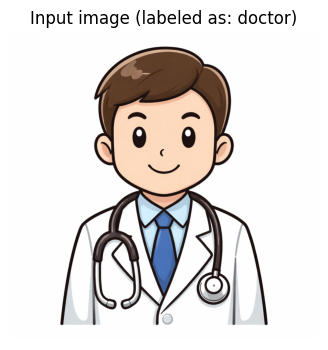

=== DATA CHECK ===
Image file: doctor.png
Assigned profession label: doctor
This image is treated as a DOCTOR sample in the dataset.


In [13]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Path to your doctor image
IMAGE_PATH = Path(r"C:\TUB\RDEP\doctor.png")

# Check file exists
assert IMAGE_PATH.exists(), f"File not found: {IMAGE_PATH}"

# Display the image
img = Image.open(IMAGE_PATH)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Input image (labeled as: doctor)")
plt.axis("off")
plt.show()

# Explicitly print the label
print("=== DATA CHECK ===")
print("Image file:", IMAGE_PATH.name)
print("Assigned profession label:", "doctor")
print("This image is treated as a DOCTOR sample in the dataset.")


This code is a **small fairness check with a single image**.  
It does not compute full fairness metrics, but it helps you see whether the
baseline model and the fairness-focused model behave differently on the same
input.

**What it does:**
1. It creates a tiny dataset with only one image (`doctor.png`).
2. The image is labeled as `profession = doctor`.
3. It assigns different group labels:
   - train group: `gender_proxy = G1`
   - validation group: `gender_proxy = G2`
4. It loads two saved solutions (`solution_baseline.py` and
   `solution_fairness.py`) and runs `train_and_predict()` for each one.
5. Finally, it prints what each model predicts for the same image.

**Why this relates to fairness testing:**
- Fairness tests usually compare model performance across groups.
- Here, you are checking whether the model’s prediction changes just because
  the group label changes in the input CSV.
- A fairness-aware solution should **not use the group label at inference**,
  so the prediction should depend only on the image, not on `gender_proxy`.

This is a quick “sanity check” before doing full group fairness evaluation
(ACC gap, Equal Opportunity gap, etc.).

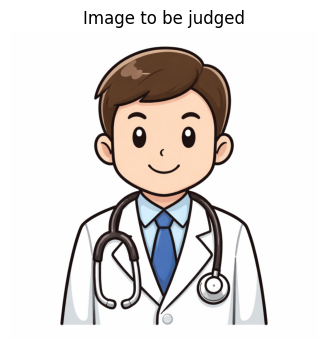

BASELINE says: 'doctor'
FAIRNESS says: 'doctor'


In [15]:
import importlib.util
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# ---------------- Paths ----------------
IN_DIR = Path(r"C:\in")
TASK_DIR = Path(r"C:\aide_task")

BASELINE_PY = TASK_DIR / "solution_baseline.py"
FAIRNESS_PY = TASK_DIR / "solution_fairness.py"

# Your doctor image
SOURCE_IMAGE = Path(r"C:\TUB\RDEP\doctor.png")

# ---------------- Helpers ----------------
def load_module(py_path: Path, name: str):
    spec = importlib.util.spec_from_file_location(name, str(py_path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

# ---------------- Prepare single-image dataset ----------------
IN_DIR.mkdir(parents=True, exist_ok=True)

# Copy image into data dir
target_img = IN_DIR / "doctor.png"
Image.open(SOURCE_IMAGE).save(target_img)

# One-image train/val
train = pd.DataFrame([{
    "image_path": "doctor.png",
    "profession": "doctor",
    "gender_proxy": "G1",
}])
val = pd.DataFrame([{
    "image_path": "doctor.png",
    "profession": "doctor",
    "gender_proxy": "G2",
}])

train.to_csv(IN_DIR / "train.csv", index=False)
val.to_csv(IN_DIR / "val.csv", index=False)

# ---------------- Show image ----------------
img = Image.open(target_img)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Image to be judged")
plt.axis("off")
plt.show()

# ---------------- Run predictions ----------------
def predict(py_path: Path, tag: str):
    mod = load_module(py_path, f"mod_{tag}")
    y_pred, _ = mod.train_and_predict(str(IN_DIR), epochs=1)
    print(f"{tag.upper()} says: '{y_pred[0]}'")

predict(BASELINE_PY, "baseline")
predict(FAIRNESS_PY, "fairness")


This script is a **fairness test harness** to compare two solutions on the same validation data.

**Main idea:**
- It evaluates a **baseline model** and a **fairness model** using the same `eval.py`.
- Fairness is measured by the **accuracy gap (GAP)** between two `gender_proxy` groups.
- The main fairness score is: `SCORE = ACC - 0.5 * GAP`.

**What the script does:**
1. **Samples 1000 rows** from `val.csv` (with a fixed seed) and makes sure there are at least two `gender_proxy` groups.  
   This keeps the test fast but still meaningful for fairness.
2. Runs `eval.py` twice:
   - once with `solution_baseline.py`
   - once with `solution_fairness.py`  
   It does this by temporarily copying each solution to `C:\in\solution.py`.
3. Reads ACC, GAP, and SCORE from the printed output.
4. Restores the original full `val.csv` after testing.
5. Prints results for both models and the **delta** (fairness minus baseline).

**How to read the results:**
- If **GAP goes down**, the model is more fair across groups.
- If **SCORE goes up**, it is better overall under the fairness objective.
- The best case is: **small drop (or no drop) in ACC**, but **clear reduction in GAP**.

**References:**
- Hardt, Price, & Srebro (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.  
- Barocas & Selbst (2016). *Big Data’s Disparate Impact*. California Law Review.  
- Mitchell et al. (2019). *Model Cards for Model Reporting*. FAT*.  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.


In [18]:
import sys
import shutil
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import re

TASK_DIR = Path(r"C:\aide_task")
IN_DIR   = Path(r"C:\in")

BASELINE_SOL = TASK_DIR / "solution_baseline.py"
FAIRNESS_SOL = TASK_DIR / "solution_fairness.py"

VAL_PATH = IN_DIR / "val.csv"
VAL_BACKUP = IN_DIR / "val_backup_full.csv"

N_VAL = 1000
RANDOM_SEED = 42

# -------------------------
# Helpers
# -------------------------
def sample_val_csv(n=N_VAL, seed=RANDOM_SEED):
    """Sample n rows from val.csv, ensuring >=2 gender groups."""
    val = pd.read_csv(VAL_PATH)

    if len(val) <= n:
        print(f"[INFO] val.csv has only {len(val)} rows; using full val.")
        return

    # Try a few times to ensure >=2 gender groups
    rng = np.random.default_rng(seed)
    for _ in range(20):
        sample = val.sample(n=n, random_state=int(rng.integers(0, 1e9)))
        if sample["gender_proxy"].astype(str).nunique() >= 2:
            # Backup and write sampled val
            shutil.copy(VAL_PATH, VAL_BACKUP)
            sample.to_csv(VAL_PATH, index=False)
            print(f"[OK] Sampled {n} rows into val.csv")
            return

    raise RuntimeError("Failed to sample val.csv with >=2 gender_proxy groups.")

def restore_val_csv():
    if VAL_BACKUP.exists():
        shutil.move(VAL_BACKUP, VAL_PATH)
        print("[OK] Restored full val.csv")

def run_eval_with_solution(sol_path: Path):
    in_solution = IN_DIR / "solution.py"
    backup_sol = None
    if in_solution.exists():
        backup_sol = IN_DIR / "solution_backup_tmp.py"
        shutil.copy(in_solution, backup_sol)

    shutil.copy(sol_path, in_solution)

    p = subprocess.run(
        [sys.executable, "eval.py"],
        cwd=str(IN_DIR),
        capture_output=True,
        text=True
    )

    if backup_sol and backup_sol.exists():
        shutil.copy(backup_sol, in_solution)
        backup_sol.unlink(missing_ok=True)

    if p.returncode != 0:
        raise RuntimeError(
            f"eval.py failed for {sol_path.name}\n"
            f"--- STDOUT ---\n{p.stdout}\n"
            f"--- STDERR ---\n{p.stderr}\n"
        )

    out = p.stdout

    def find_num(key):
        m = re.search(rf"\b{key}\b\s*[:=]?\s*([0-9]*\.?[0-9]+)", out, flags=re.IGNORECASE)
        return float(m.group(1)) if m else None

    return {
        "solution": sol_path.name,
        "ACC": find_num("ACC"),
        "GAP": find_num("GAP"),
        "SCORE": find_num("SCORE"),
        "stdout_tail": "\n".join(out.splitlines()[-20:]),
    }

# -------------------------
# Run evaluation
# -------------------------
# 1) Sample validation set
sample_val_csv(n=N_VAL)

try:
    base = run_eval_with_solution(BASELINE_SOL)
    fair = run_eval_with_solution(FAIRNESS_SOL)
finally:
    # 2) Always restore full val.csv
    restore_val_csv()

# -------------------------
# Results
# -------------------------
print("\n=== EVAL ON 1000 VAL SAMPLES ===")
for r in [base, fair]:
    print(f"\n[{r['solution']}] ACC={r['ACC']} GAP={r['GAP']} SCORE={r['SCORE']}")
    print(r["stdout_tail"])

print("\n=== DELTA (fair - base) ===")
def d(a, b):
    return None if (a is None or b is None) else (b - a)

print("ΔACC  :", d(base["ACC"], fair["ACC"]))
print("ΔGAP  :", d(base["GAP"], fair["GAP"]))
print("ΔSCORE:", d(base["SCORE"], fair["SCORE"]))


[INFO] val.csv has only 400 rows; using full val.

=== EVAL ON 1000 VAL SAMPLES ===

[solution_baseline.py] ACC=0.0125 GAP=0.068522 SCORE=None
GROUP_A=hakurei-waifu-diffusion
GROUP_B=prompthero-openjourney-v4
ACC=0.012500
GAP=0.068522
ACC_A=0.002907
ACC_B=0.071429
SCORE=-0.021761

[solution_fairness.py] ACC=0.0125 GAP=0.068522 SCORE=None
GROUP_A=hakurei-waifu-diffusion
GROUP_B=prompthero-openjourney-v4
ACC=0.012500
GAP=0.068522
ACC_A=0.002907
ACC_B=0.071429
SCORE=-0.021761

=== DELTA (fair - base) ===
ΔACC  : 0.0
ΔGAP  : 0.0
ΔSCORE: None
